##Auto Encoder


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2326 - val_loss: 0.1519
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1364 - val_loss: 0.1226
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1181 - val_loss: 0.1112
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1112

Test Loss: 0.11120714992284775
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


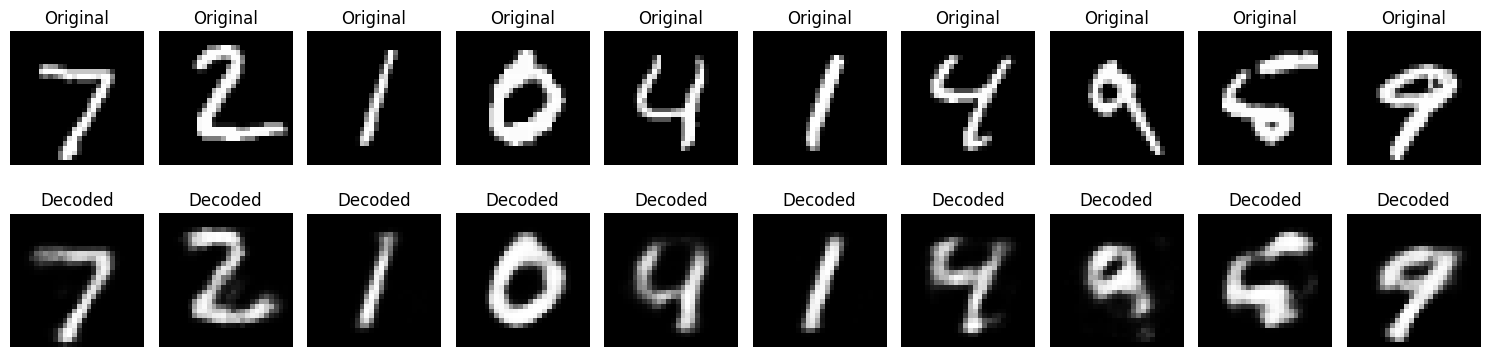

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# ------------------------------------
# Load MNIST Dataset
# ------------------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-dimensional vectors
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

# ------------------------------------
# Build Autoencoder
# ------------------------------------
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation="relu")(input_img)
encoded = Dense(32, activation="relu")(encoded)

# Decoder
decoded = Dense(128, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

# Create Model
autoencoder = Model(input_img, decoded)

# ------------------------------------
# Compile Model
# ------------------------------------
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# ------------------------------------
# Model Summary
# ------------------------------------
autoencoder.summary()

# ------------------------------------
# Train
# ------------------------------------
history = autoencoder.fit(
    x_train,
    x_train,                 # Target is the input itself
    epochs=3,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# ------------------------------------
# Evaluate
# ------------------------------------
loss = autoencoder.evaluate(x_test, x_test)

print("\nTest Loss:", loss)

# ------------------------------------
# Reconstruct Images
# ------------------------------------
reconstructed = autoencoder.predict(x_test[:10])

# ------------------------------------
# Display Results
# ------------------------------------
plt.figure(figsize=(15,4))

for i in range(10):

    # Original Image
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed Image
    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed[i].reshape(28,28), cmap="gray")
    plt.title("Decoded")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Sparse

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.4091 - val_loss: 0.2701
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2662 - val_loss: 0.2641
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2638 - val_loss: 0.2632
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2632
Test Loss: 0.2631624639034271
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


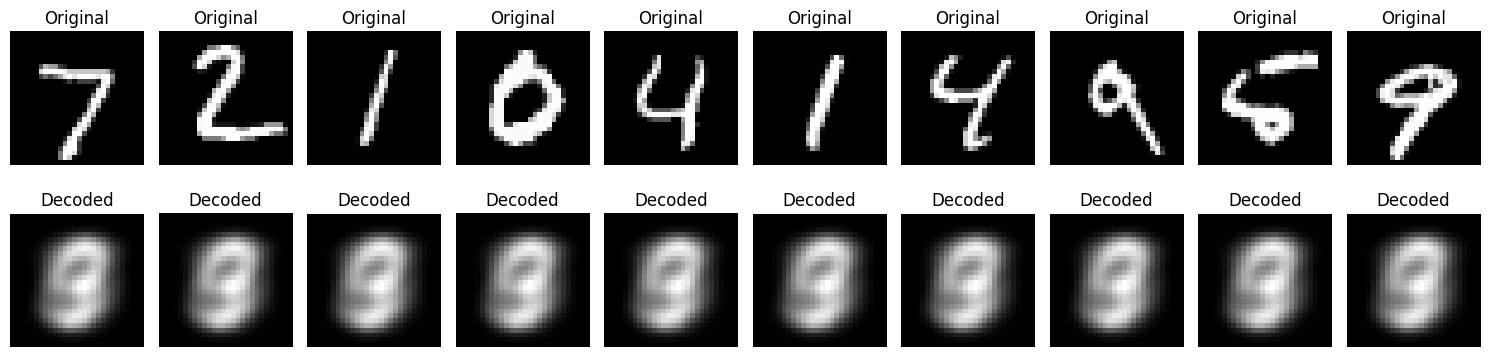

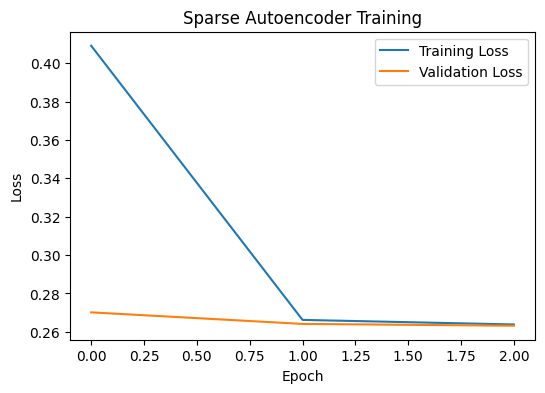

In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# ------------------------------------
# Load MNIST Dataset
# ------------------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

# ------------------------------------
# Build Sparse Autoencoder
# ------------------------------------
input_img = Input(shape=(784,))

# Encoder with sparsity constraint
encoded = Dense(
    128,
    activation="relu"
)(input_img)

encoded = Dense(
    32,
    activation="relu",
    activity_regularizer=regularizers.l1(1e-4)
)(encoded)

# Decoder
decoded = Dense(
    128,
    activation="relu"
)(encoded)

decoded = Dense(
    784,
    activation="sigmoid"
)(decoded)

# Create model
sparse_autoencoder = Model(input_img, decoded)

# ------------------------------------
# Compile
# ------------------------------------
sparse_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# ------------------------------------
# Summary
# ------------------------------------
sparse_autoencoder.summary()

# ------------------------------------
# Train
# ------------------------------------
history = sparse_autoencoder.fit(
    x_train,
    x_train,
    epochs=3,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# ------------------------------------
# Evaluate
# ------------------------------------
loss = sparse_autoencoder.evaluate(x_test, x_test)

print("Test Loss:", loss)

# ------------------------------------
# Reconstruction
# ------------------------------------
reconstructed = sparse_autoencoder.predict(x_test[:10])

# ------------------------------------
# Display Results
# ------------------------------------
plt.figure(figsize=(15,4))

for i in range(10):

    # Original Image
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed Image
    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed[i].reshape(28,28), cmap="gray")
    plt.title("Decoded")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------
# Plot Training Loss
# ------------------------------------
plt.figure(figsize=(6,4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sparse Autoencoder Training")

plt.legend()

plt.show()

#VAE


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 256)       │    200,960 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 2)         │        514 │ dense_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 2)         │        514 │ dense_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ dense_43[0][0],   │
│ (Sampling)          │                   │            │ dense_44[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - kl_loss: 3.8619 - loss: 191.1902 - reconstruction_loss: 187.3282 
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - kl_loss: 3.1111 - loss: 171.8702 - reconstruction_loss: 168.7590
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 3.3222 - loss: 163.2900 - reconstruction_loss: 159.9677
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


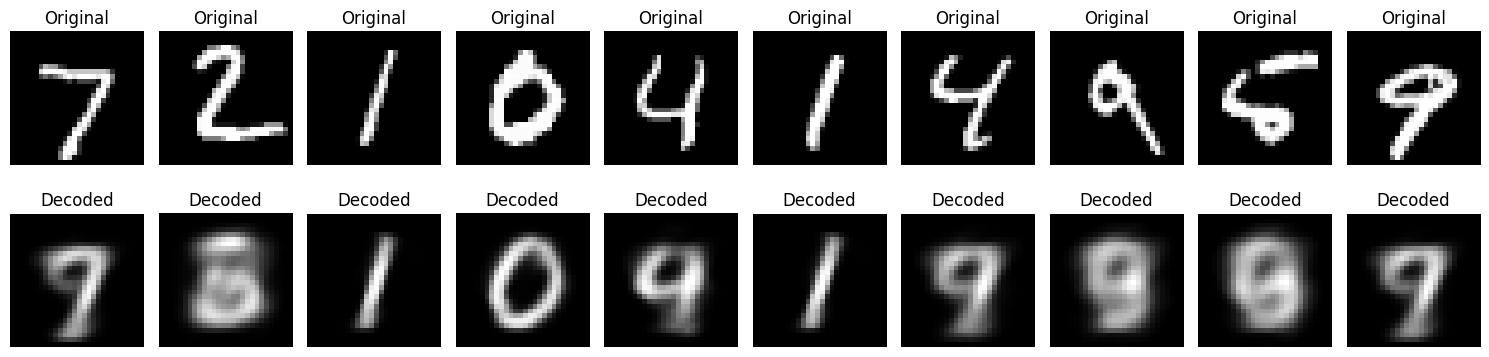

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ---------------------------------------
# Load MNIST
# ---------------------------------------
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

latent_dim = 2

# ---------------------------------------
# Sampling Layer
# ---------------------------------------

class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(shape=tf.shape(z_mean))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# ---------------------------------------
# Encoder
# ---------------------------------------

encoder_inputs = keras.Input(shape=(784,))

x = layers.Dense(256, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)

z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="Encoder"
)

encoder.summary()

# ---------------------------------------
# Decoder
# ---------------------------------------

latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(256, activation="relu")(latent_inputs)

decoder_outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="Decoder"
)

decoder.summary()

# ---------------------------------------
# VAE Model
# ---------------------------------------

class VAE(keras.Model):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                )
            ) * 784

            kl_loss = -0.5 * tf.reduce_mean(
                1 +
                z_log_var -
                tf.square(z_mean) -
                tf.exp(z_log_var)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

# ---------------------------------------
# Compile
# ---------------------------------------

vae = VAE(encoder, decoder)

vae.compile(
    optimizer="adam"
)

# ---------------------------------------
# Train
# ---------------------------------------

vae.fit(
    x_train,
    epochs=3,
    batch_size=256
)

# ---------------------------------------
# Reconstruction
# ---------------------------------------

_, _, latent = encoder.predict(x_test[:10])

reconstructed = decoder.predict(latent)

# ---------------------------------------
# Display
# ---------------------------------------

plt.figure(figsize=(15,4))

for i in range(10):

    plt.subplot(2,10,i+1)
    plt.imshow(
        x_test[i].reshape(28,28),
        cmap="gray"
    )
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2,10,i+11)
    plt.imshow(
        reconstructed[i].reshape(28,28),
        cmap="gray"
    )
    plt.axis("off")
    plt.title("Decoded")

plt.tight_layout()
plt.show()

#Adverserial Autoencoders

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

(x_train,_), (x_test,_) = mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = x_train.reshape((-1,784))
x_test = x_test.reshape((-1,784))

input_dim = 784
latent_dim = 32
batch_size = 128
epochs = 20

optimizer = Adam(0.0002)

encoder_input = Input(shape=(input_dim,))

x = Dense(128, activation='relu')(encoder_input)
latent = Dense(latent_dim)(x)

encoder = Model(encoder_input, latent, name="Encoder")

encoder.summary()

decoder_input = Input(shape=(latent_dim,))

x = Dense(128, activation='relu')(decoder_input)
decoder_output = Dense(input_dim, activation='sigmoid')(x)

decoder = Model(decoder_input, decoder_output, name="Decoder")

decoder.summary()

autoencoder_input = Input(shape=(input_dim,))

encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = Model(autoencoder_input, decoded)

autoencoder.compile(
    optimizer=optimizer,
    loss='binary_crossentropy'
)

autoencoder.summary()

discriminator_input = Input(shape=(latent_dim,))

x = Dense(64, activation='relu')(discriminator_input)
x = Dense(32, activation='relu')(x)

validity = Dense(1, activation='sigmoid')(x)

discriminator = Model(discriminator_input, validity)

discriminator.compile(
    optimizer=Adam(0.0002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

discriminator.summary()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,608 (408.62 KB)

 Trainable params: 104,608 (408.62 KB)

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
discriminator.trainable = False

aae_input = Input(shape=(input_dim,))

latent = encoder(aae_input)
validity = discriminator(latent)

adversarial_model = Model(aae_input, validity)

adversarial_model.compile(
    optimizer=Adam(0.0002),
    loss='binary_crossentropy'
)



Epoch 1/20 completed
Epoch 2/20 completed
Epoch 3/20 completed
Epoch 4/20 completed
Epoch 5/20 completed
Epoch 6/20 completed
Epoch 7/20 completed
Epoch 8/20 completed
Epoch 9/20 completed
Epoch 10/20 completed
Epoch 11/20 completed
Epoch 12/20 completed
Epoch 13/20 completed
Epoch 14/20 completed
Epoch 15/20 completed
Epoch 16/20 completed
Epoch 17/20 completed
Epoch 18/20 completed
Epoch 19/20 completed
Epoch 20/20 completed
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


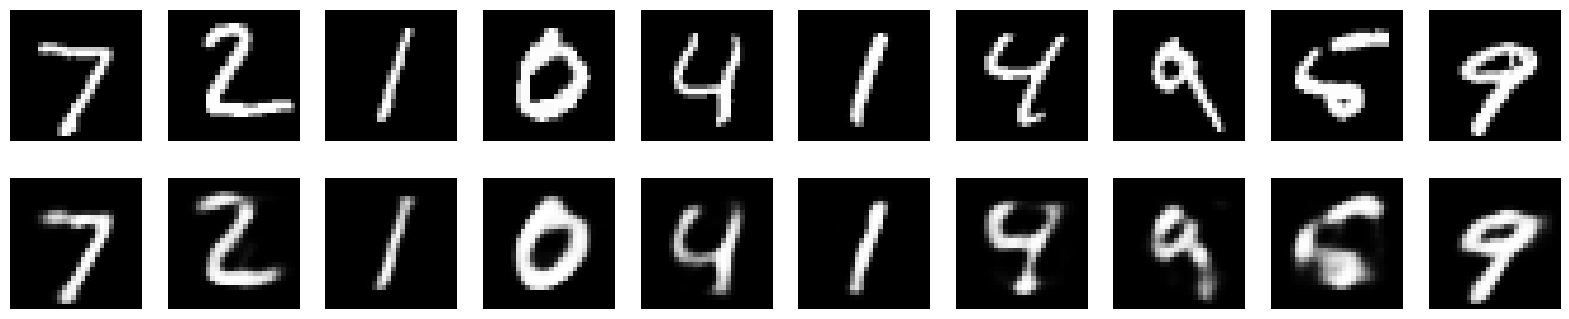

In [4]:
num_batches = x_train.shape[0] // batch_size

for epoch in range(epochs):

    for batch in range(num_batches):

        idx = np.random.randint(0, x_train.shape[0], batch_size)

        imgs = x_train[idx]

        # -------------------------------------------------
        # Step 1 : Train Autoencoder
        # -------------------------------------------------

        autoencoder.train_on_batch(imgs, imgs)

        # -------------------------------------------------
        # Step 2 : Train Discriminator
        # -------------------------------------------------

        latent_fake = encoder.predict(imgs, verbose=0)

        latent_real = np.random.normal(
            size=(batch_size, latent_dim)
        )

        real_labels = np.ones((batch_size,1))
        fake_labels = np.zeros((batch_size,1))

        discriminator.trainable = True

        d_loss_real = discriminator.train_on_batch(
            latent_real,
            real_labels
        )

        d_loss_fake = discriminator.train_on_batch(
            latent_fake,
            fake_labels
        )

        # -------------------------------------------------
        # Step 3 : Train Encoder to Fool Discriminator
        # -------------------------------------------------

        discriminator.trainable = False

        adversarial_model.train_on_batch(
            imgs,
            real_labels
        )

    print(
        f"Epoch {epoch+1}/{epochs} completed"
    )

decoded_imgs = autoencoder.predict(x_test[:10])

plt.figure(figsize=(20,4))

for i in range(10):

    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


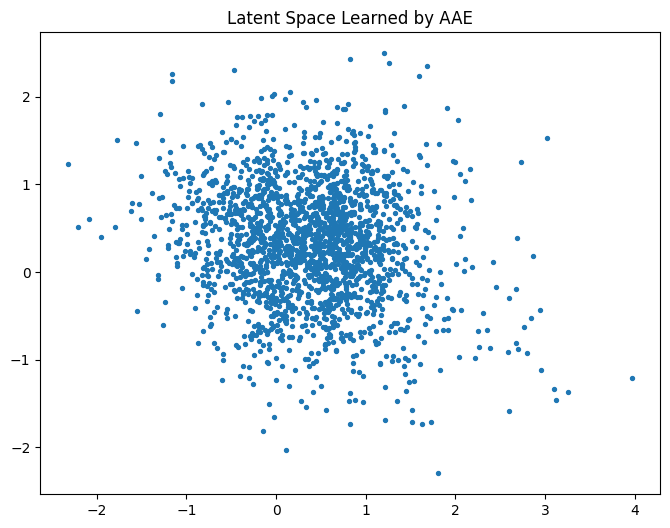

In [5]:
latent_vectors = encoder.predict(x_test[:2000])

plt.figure(figsize=(8,6))

plt.scatter(
    latent_vectors[:,0],
    latent_vectors[:,1],
    s=8
)

plt.title("Latent Space Learned by AAE")

plt.show()

#Adaptive AutoEncoder

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = x_train.reshape((-1,784))
x_test = x_test.reshape((-1,784))

In [12]:
input_img = Input(shape=(784,))

x = Dense(256, activation='relu')(input_img)

latent = Dense(
    128,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-5)
)(x)

x = Dense(256, activation='relu')(latent)

output = Dense(784, activation='sigmoid')(x)

adaptive_autoencoder = Model(input_img, output)

encoder = Model(input_img, latent)


adaptive_autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)


history = adaptive_autoencoder.fit(
    x_train,
    x_train,
    epochs=6,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test,x_test)
)

Epoch 1/6
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.2887 - val_loss: 0.2147
Epoch 2/6
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1913 - val_loss: 0.1785
Epoch 3/6
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1725 - val_loss: 0.1656
Epoch 4/6
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1634 - val_loss: 0.1582
Epoch 5/6
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1564 - val_loss: 0.1526
Epoch 6/6
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.1521 - val_loss: 0.1493


In [13]:
latent_vectors = encoder.predict(x_test)

mean_activation = np.mean(np.abs(latent_vectors), axis=0)

print(mean_activation)

threshold = 0.05

active_neurons = np.where(mean_activation > threshold)[0]

print("Original Latent Size :", latent_vectors.shape[1])
print("Active Latent Size :", len(active_neurons))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[1.4850562e-05 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 4.1971752e-01 7.5535945e-06 0.0000000e+00 3.1448522e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 4.3100473e-01 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 4.6107045e-01
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 7.8583726e-06 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 3.9351660e-01 2.6431017e-06 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 3.5216719e-01 0.0000000e+00 0.00000

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


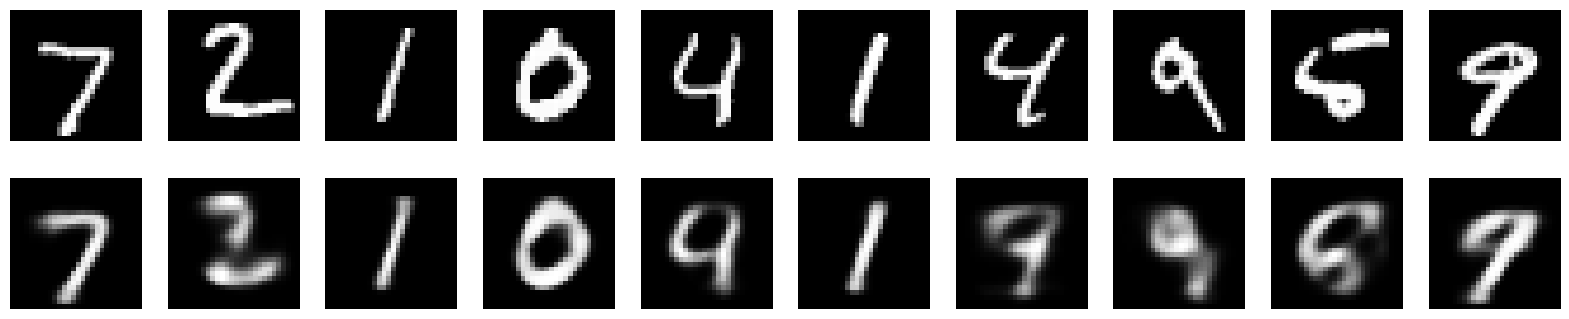

In [14]:
decoded_imgs = adaptive_autoencoder.predict(x_test)


n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    ax = plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    ax = plt.subplot(2,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()